# Data

In [1]:
import time
import pandas as pd
import os
from nba_api.stats.endpoints import leaguegamelog

def fetch_and_save_nba_data(filename="nba_games_jan14_2026.xlsx"):
    # 1. Fetch Data
    seasons = ["2020-21", "2021-22", "2022-23", "2023-24", "2024-25", "2025-26"]
    all_games = []

    print("Fetching NBA game logs...")
    for season in seasons:
        try:
            gamelog = leaguegamelog.LeagueGameLog(
                season=season, 
                season_type_all_star="Regular Season"
            ).get_data_frames()[0]
            
            all_games.append(gamelog)
            print(f"Fetched season {season}")
            time.sleep(0.6)
        except Exception as e:
            print(f"Error fetching {season}: {e}")

    # 2. Combine and Filter
    if all_games:
        games_df = pd.concat(all_games, ignore_index=True)
        games_df['GAME_DATE'] = pd.to_datetime(games_df['GAME_DATE'])
        
        # Filter strictly up to Jan 14, 2026
        cutoff_date = pd.to_datetime("2026-01-16") #16 might be better
        filtered_df = games_df[games_df['GAME_DATE'] <= cutoff_date]
        
        # 3. Save
        filtered_df.to_excel(filename, index=False)
        print(f"Success: {len(filtered_df)} rows saved to {filename}")
    else:
        print("No data fetched.")

# ==============================================================================
# UNCOMMENT THE LINE BELOW TO RUN DATA COLLECTION (Run once, then comment out)
# ==============================================================================
#fetch_and_save_nba_data()

In [2]:
import pandas as pd

# Load the saved data
games_df = pd.read_excel("nba_games_jan14_2026.xlsx")

# Ensure GAME_DATE is datetime (crucial for your feature engineering later)
games_df['GAME_DATE'] = pd.to_datetime(games_df['GAME_DATE'])

games_df['HOME_GAME'] = games_df['MATCHUP'].str.contains('vs.').astype(int)

print(f"Loaded {len(games_df)} rows.")
print(f"Date Range: {games_df['GAME_DATE'].min()} to {games_df['GAME_DATE'].max()}")

Loaded 13234 rows.
Date Range: 2020-12-22 00:00:00 to 2026-01-16 00:00:00


In [3]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr  # <--- Added this import

def feature_engineering(df):
    # --- 1. Merge Team + Opponent ---
    opp_df = df.rename(columns={c: 'OPP_'+c for c in df.columns if c != 'GAME_ID'})
    df = df.merge(opp_df, on='GAME_ID')
    # Filter to ensure we don't have duplicate rows (keep only distinct team vs opponent)
    df = df[df['TEAM_ABBREVIATION'] != df['OPP_TEAM_ABBREVIATION']].reset_index(drop=True)

    # --- 2. Normalize ---
    df['MIN'] = pd.to_numeric(df['MIN'], errors='coerce').fillna(240)
    for c in ['PTS','AST','REB','OREB','DREB','STL','BLK','TOV','FGA','FGM','FTA','FG3A','FG3M']:
        if c in df: df[f'{c}_PER48'] = df[c] / df['MIN'] * 48

    # --- 3. Possessions & Ratings ---
    est_poss = lambda fga, fta, oreb, tov: fga + 0.44 * fta - oreb + tov
    df['TEAM_POSSESSIONS'] = est_poss(df['FGA'], df['FTA'], df['OREB'], df['TOV'])
    df['OPP_POSSESSIONS'] = est_poss(df['OPP_FGA'], df['OPP_FTA'], df['OPP_OREB'], df['OPP_TOV'])

    df['PACE'] = 120 * (df['TEAM_POSSESSIONS'] + df['OPP_POSSESSIONS']) / df['MIN']
    df['OFF_RTG'] = 100 * df['PTS'] / df['TEAM_POSSESSIONS'].replace(0, 1)
    df['DEF_RTG'] = 100 * df['OPP_PTS'] / df['OPP_POSSESSIONS'].replace(0, 1)
    df['NET_RTG'] = df['OFF_RTG'] - df['DEF_RTG']

    # --- 4. Efficiency & Style ---
    fga_adj = df['FGA'].replace(0, 1)
    df['TS_PCT'] = df['PTS'] / (2 * (df['FGA'] + 0.44 * df['FTA'])).replace(0, 1)
    df['EFG_PCT'] = (df['FGM'] + 0.5 * df.get('FG3M', 0)) / fga_adj
    df['TOV_PCT'] = df['TOV'] / (df['FGA'] + 0.44 * df['FTA'] + df['TOV']).replace(0, 1)
    df['REB_PCT'] = df['REB'] / (df['REB'] + df['OPP_REB']).replace(0, 1)

    df['FG3A_RATE'] = df.get('FG3A', 0) / fga_adj
    df['FTA_RATE'] = df['FTA'] / fga_adj
    df['ORB_PCT'] = df['OREB'] / (df['OREB'] + df['OPP_DREB']).replace(0, 1)

    # --- 5. Rankings ---
    g_date = df.groupby('GAME_DATE')
    df['OFF_RANK'] = g_date['OFF_RTG'].rank(ascending=False, method='dense')
    df['DEF_RANK'] = g_date['DEF_RTG'].rank(ascending=True, method='dense')
    df['NET_RANK'] = g_date['NET_RTG'].rank(ascending=False, method='dense')

    # --- 6. Fatigue ---
    df = df.sort_values(['TEAM_ABBREVIATION', 'GAME_DATE'])
    df['DAYS_SINCE_LAST'] = df.groupby('TEAM_ABBREVIATION')['GAME_DATE'].diff().dt.days.fillna(3).clip(0, 7)
    df['IS_BACK_TO_BACK'] = (df['DAYS_SINCE_LAST'] <= 1).astype(int)

    # --- 7. Rolling Stats ---
    grp = df.groupby('TEAM_ABBREVIATION')
    cols = ['PACE','OFF_RTG','DEF_RTG','NET_RTG','TS_PCT','EFG_PCT','TOV_PCT','REB_PCT','OFF_RANK','DEF_RANK','NET_RANK','PTS','FG3A_RATE','FTA_RATE','ORB_PCT']
    for c in cols:
        shifted = grp[c].shift(1)
        df[f'{c}_L5'] = shifted.transform(lambda x: x.rolling(5, min_periods=1).mean())
        df[f'{c}_L10'] = shifted.transform(lambda x: x.rolling(10, min_periods=1).mean())

    # --- 8. Variance ---
    for c in ['PACE', 'TS_PCT', 'EFG_PCT', 'OFF_RTG', 'DEF_RTG', 'FG3A_RATE']:
        shifted = grp[c].shift(1)
        df[f'{c}_STD_L5'] = shifted.transform(lambda x: x.rolling(5, min_periods=2).std())
        df[f'{c}_STD_L10'] = shifted.transform(lambda x: x.rolling(10, min_periods=3).std())

    std_cols = [c for c in df if '_STD_' in c]
    df[std_cols] = df[std_cols].fillna(df[std_cols].median())

    # --- 9. Intensity ---
    df['OFF_RTG_L5_PCT'] = df.groupby('GAME_DATE')['OFF_RTG_L5'].rank(pct=True)
    df['DEF_RTG_L5_PCT'] = 1 - df.groupby('GAME_DATE')['DEF_RTG_L5'].rank(pct=True)
    df['TEAM_INTENSITY_L5'] = 0.5 * df['OFF_RTG_L5_PCT'] + 0.5 * (1 - df['DEF_RTG_L5_PCT'])

    # --- 10. Matchups ---
    # This step transforms the dataframe from "Team View" to "Matchup View"
    home = df[df['HOME_GAME'] == 1].add_suffix('_HOME').rename(columns={'GAME_ID_HOME': 'GAME_ID'})
    away = df[df['HOME_GAME'] == 0].add_suffix('_AWAY').rename(columns={'GAME_ID_AWAY': 'GAME_ID'})
    matchup_df = pd.merge(home, away, on='GAME_ID')

    # --- 11. Interactions ---
    for c in ['PACE', 'FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'OFF_RTG']:
        matchup_df[f'{c}_L5_MEAN'] = (matchup_df[f'{c}_L5_HOME'] + matchup_df[f'{c}_L5_AWAY']) / 2

    matchup_df['GAME_VOLATILITY'] = sum(matchup_df[f'{c}_STD_L10_{side}'] for c in ['PACE', 'TS_PCT', 'OFF_RTG'] for side in ['HOME', 'AWAY'])
    matchup_df['PACE_DIFF'] = matchup_df['PACE_L10_HOME'] - matchup_df['PACE_L10_AWAY']
    matchup_df['NET_RANK_DIFF'] = matchup_df['NET_RANK_L10_HOME'] - matchup_df['NET_RANK_L10_AWAY']
    matchup_df['NET_RANK_GAP'] = abs(matchup_df['NET_RANK_L5_HOME'] - matchup_df['NET_RANK_L5_AWAY'])

    print("✅ Feature Engineering Complete")
    return matchup_df

games_df = feature_engineering(games_df)

✅ Feature Engineering Complete


In [4]:
def construct_lines(df):
    # --- 1. Base Metrics ---
    df["TOTAL_PTS"] = df["PTS_HOME"] + df["PTS_AWAY"]
    df["HOME_WIN"] = (df["WL_HOME"] == "W").astype(int)

    # Pace & Volatility
    df["EXP_PACE"] = sum(0.7 * df[f"PACE_L5_{s}"] + 0.3 * df[f"PACE_L10_{s}"] for s in ['HOME', 'AWAY']) / 2
    df["PACE_VOLATILITY"] = (df["PACE_STD_L5_HOME"] + df["PACE_STD_L5_AWAY"]) / 2
    df["PACE_VOL_ADJ"] = df["PACE_VOLATILITY"] * 0.3

    # Fatigue
    df["PACE_FATIGUE_ADJ"] = -2.0 * (df["IS_BACK_TO_BACK_HOME"] + df["IS_BACK_TO_BACK_AWAY"])
    df["REST_ADVANTAGE"] = (df["DAYS_SINCE_LAST_HOME"].clip(0, 5) - df["DAYS_SINCE_LAST_AWAY"].clip(0, 5)) * 0.1
    df["EXP_PACE_ADJ"] = df["EXP_PACE"] + df["PACE_FATIGUE_ADJ"] + df["PACE_VOL_ADJ"]

    # Efficiency (PPP)
    for side in ['HOME', 'AWAY']:
        for stat in ['OFF_RTG', 'DEF_RTG']:
            df[f"{stat}_{side}_WEIGHTED"] = 0.65 * df[f"{stat}_L5_{side}"] + 0.35 * df[f"{stat}_L10_{side}"]

    df["EXP_PPP_HOME"] = df["OFF_RTG_HOME_WEIGHTED"] / df["DEF_RTG_AWAY_WEIGHTED"].replace(0, 1)
    df["EXP_PPP_AWAY"] = df["OFF_RTG_AWAY_WEIGHTED"] / df["DEF_RTG_HOME_WEIGHTED"].replace(0, 1)
    df["EXP_PPP"] = (df["EXP_PPP_HOME"] + df["EXP_PPP_AWAY"]) / 2

    # --- 2. Style Adjustments ---
    factors = [
        ("THREE_PT", "FG3A_RATE", 0.35, 8), ("FTA", "FTA_RATE", 0.25, 6),
        ("ORB", "ORB_PCT", 0.25, 10), ("TOV", "TOV_PCT", 0.13, -15)
    ]
    for name, col, base, mult in factors:
        df[f"{name}_FACTOR"] = (df[f"{col}_L5_HOME"] + df[f"{col}_L5_AWAY"]) / 2
        df[f"{name}_ADJ"] = (df[f"{name}_FACTOR"] - base) * mult

    df["SHOOTING_EFFICIENCY"] = (df["TS_PCT_L5_HOME"] + df["TS_PCT_L5_AWAY"]) / 2
    df["SHOOTING_ADJ"] = (df["SHOOTING_EFFICIENCY"] - 0.56) * 50
    df["MISMATCH_FACTOR"] = df["NET_RANK_GAP"] / 30
    df["MISMATCH_ADJ"] = df["MISMATCH_FACTOR"] * 1.5

    # --- 3. Line Construction ---
    SCALING_FACTOR = 2.31
    df["RAW_EXPECTED_TOTAL"] = df["EXP_PACE_ADJ"] * df["EXP_PPP"] * SCALING_FACTOR
    df["TOTAL_ADJUSTMENTS"] = sum(df[f"{k}_ADJ"] for k in ["THREE_PT", "FTA", "ORB", "TOV", "SHOOTING", "MISMATCH"]) + df["REST_ADVANTAGE"]
    df["LINE_RAW"] = df["RAW_EXPECTED_TOTAL"] + df["TOTAL_ADJUSTMENTS"]

    # Calibration
    df = df.sort_values("GAME_DATE_HOME").reset_index(drop=True)
    df["EXPANDING_SCALE"] = [df.loc[:i-1, "TOTAL_PTS"].mean() / df.loc[:i-1, "LINE_RAW"].mean() if i >= 50 else np.nan for i in range(len(df))]
    df["EXPANDING_SCALE"].fillna(df["TOTAL_PTS"].mean() / df["LINE_RAW"].mean(), inplace=True)
    df["LINE_CALIBRATED"] = df["LINE_RAW"] * df["EXPANDING_SCALE"]

    # Range Adjustment & Finalization
    def adj_range(x): return x + 8 if x < 210 else x + 4 if x < 215 else x - 8 if x > 245 else x - 4 if x > 240 else x
    df["LINE_RANGE_ADJ"] = df["LINE_CALIBRATED"].apply(adj_range)
    df["LINE_ROUNDED"] = (df["LINE_RANGE_ADJ"] * 2).round() / 2
    df["LINE_BOUNDED"] = df["LINE_ROUNDED"].clip(180, 260)
    
    # Final Bias
    bias = (df["LINE_BOUNDED"] - df["TOTAL_PTS"]).mean()
    df["LINE"] = ((df["LINE_BOUNDED"] - bias) * 2).round() / 2
    df["LINE"] = df["LINE"].clip(180, 260)
    
    df["OVER"] = (df["TOTAL_PTS"] > df["LINE"]).astype(int)
    df["ERROR"] = df["TOTAL_PTS"] - df["LINE"]

    # Stats
    mae = df['ERROR'].abs().mean()
    rmse = np.sqrt((df['ERROR']**2).mean())
    over_pct = df['OVER'].mean()*100
    valid = np.isfinite(df["LINE"]) & np.isfinite(df["TOTAL_PTS"])
    corr = spearmanr(df.loc[valid, 'LINE'], df.loc[valid, 'TOTAL_PTS'])[0]

    print(f"✅ Line Construction Complete")
    print(f"MAE: {mae:.2f} | RMSE: {rmse:.2f} | Over%: {over_pct:.1f}% | Correlation: {corr:.3f}")
    
    return df

games_df = construct_lines(games_df)

✅ Line Construction Complete
MAE: 16.83 | RMSE: 21.15 | Over%: 48.2% | Correlation: 0.120


C:\Users\Varic\AppData\Local\Temp\ipykernel_26056\2945799135.py:48: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["EXPANDING_SCALE"].fillna(df["TOTAL_PTS"].mean() / df["LINE_RAW"].mean(), inplace=True)


⚙️ Starting Regime Clustering...


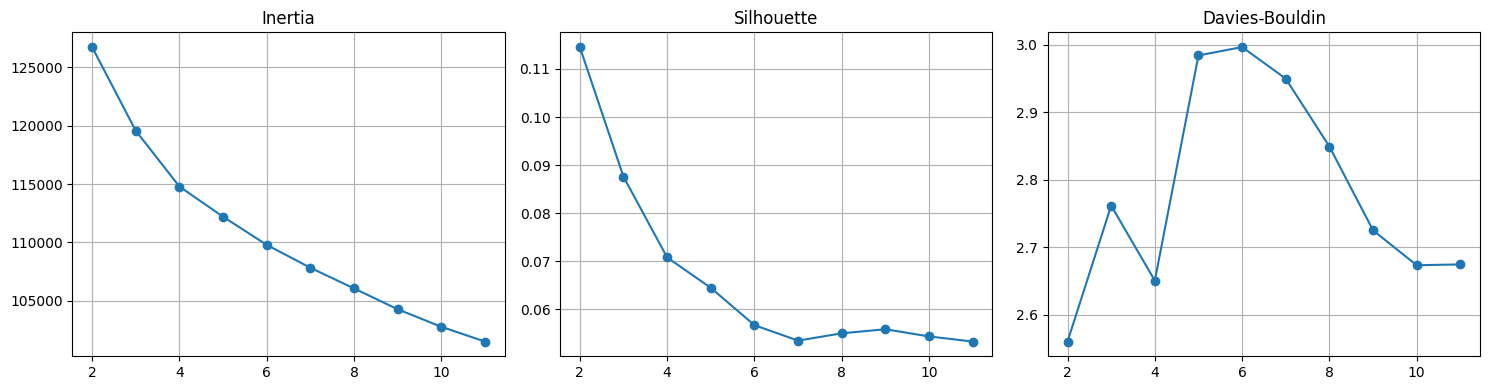

✅ Regime Clustering Complete (k=3).
   Labels Found: ['Defensive Grind' 'Standard Game' 'Mismatch/Blowout Risk']


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score

def cluster_regimes(matchup_df):
    print("⚙️ Starting Regime Clustering...")
    
    # --- 1. Interaction Features ---
    # Create features specifically for clustering
    matchup_df['PACE_L5_MEAN'] = (matchup_df['PACE_L5_HOME'] + matchup_df['PACE_L5_AWAY']) / 2
    matchup_df['PACE_L5_DIFF'] = matchup_df['PACE_L5_HOME'] - matchup_df['PACE_L5_AWAY']
    matchup_df['COMBINED_OFF_RTG_L5'] = matchup_df['OFF_RTG_L5_HOME'] + matchup_df['OFF_RTG_L5_AWAY']
    matchup_df['COMBINED_DEF_RTG_L5'] = matchup_df['DEF_RTG_L5_HOME'] + matchup_df['DEF_RTG_L5_AWAY']
    matchup_df['OFF_DEF_ADVANTAGE'] = ((matchup_df['OFF_RTG_L5_HOME'] - matchup_df['DEF_RTG_L5_AWAY']) + 
                                       (matchup_df['OFF_RTG_L5_AWAY'] - matchup_df['DEF_RTG_L5_HOME'])) / 2

    for c in ['FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'TS_PCT', 'EFG_PCT', 'TOV_PCT']:
        matchup_df[f'{c}_L5_MEAN'] = (matchup_df[f'{c}_L5_HOME'] + matchup_df[f'{c}_L5_AWAY']) / 2

    matchup_df['TOTAL_VOLATILITY_L5'] = sum(matchup_df[f'{c}_STD_L5_{s}'] 
                                            for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE'] 
                                            for s in ['HOME', 'AWAY'])
    matchup_df['NET_RANK_GAP'] = abs(matchup_df['NET_RANK_L5_HOME'] - matchup_df['NET_RANK_L5_AWAY'])
    matchup_df['FATIGUE_FACTOR'] = matchup_df['IS_BACK_TO_BACK_HOME'] + matchup_df['IS_BACK_TO_BACK_AWAY']

    # --- 2. Clustering Setup ---
    regime_features = [
        "PACE_L5_MEAN", "COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", "FG3A_RATE_L5_MEAN", 
        "TS_PCT_L5_MEAN", "EFG_PCT_L5_MEAN", "FTA_RATE_L5_MEAN", "ORB_PCT_L5_MEAN", 
        "OFF_DEF_ADVANTAGE", "PACE_L5_DIFF", "NET_RANK_GAP", "TOTAL_VOLATILITY_L5",
        "PACE_STD_L5_HOME", "PACE_STD_L5_AWAY", "FG3A_RATE_STD_L5_HOME", "FG3A_RATE_STD_L5_AWAY", 
        "TOV_PCT_L5_MEAN", "FATIGUE_FACTOR", "OFF_RTG_L5_HOME", "OFF_RTG_L5_AWAY", 
        "DEF_RTG_L5_HOME", "DEF_RTG_L5_AWAY"
    ]

    # Create a copy for clustering
    regime_df = matchup_df[regime_features].dropna().copy()
    X_regime_scaled = StandardScaler().fit_transform(regime_df)

    # --- 3. Optimal Clusters (Graphs Only) ---
    inertias, silhouettes, db_scores = [], [], []
    K_range = range(2, 12)

    for k in K_range:
        km = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=500).fit(X_regime_scaled)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X_regime_scaled, km.labels_))
        db_scores.append(davies_bouldin_score(X_regime_scaled, km.labels_))

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    for ax, data, title in zip(axes, [inertias, silhouettes, db_scores], ['Inertia', 'Silhouette', 'Davies-Bouldin']):
        ax.plot(K_range, data, 'o-')
        ax.set_title(title)
        ax.grid(True)
    plt.tight_layout()
    plt.show()

    # --- 4. Final Model (Hardcoded k=3) ---
    optimal_k = 3
    kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=20).fit(X_regime_scaled)
    regime_df['REGIME'] = kmeans_final.labels_

    # Calculate summary for labeling
    regime_summary = regime_df.groupby('REGIME')[['PACE_L5_MEAN', 'COMBINED_OFF_RTG_L5', 'COMBINED_DEF_RTG_L5', 
                                                  'FG3A_RATE_L5_MEAN', 'TOTAL_VOLATILITY_L5', 'OFF_DEF_ADVANTAGE', 
                                                  'NET_RANK_GAP']].mean()

    # Dynamic Labeling Function
    def label_regime(row):
        q = regime_summary.quantile([0.25, 0.75])
        if row['PACE_L5_MEAN'] > q.loc[0.75, 'PACE_L5_MEAN'] and row['COMBINED_OFF_RTG_L5'] > q.loc[0.75, 'COMBINED_OFF_RTG_L5']: 
            return "High-Scoring Shootout"
        if row['PACE_L5_MEAN'] < q.loc[0.25, 'PACE_L5_MEAN'] and row['COMBINED_DEF_RTG_L5'] < q.loc[0.25, 'COMBINED_DEF_RTG_L5']: 
            return "Defensive Grind"
        if row['FG3A_RATE_L5_MEAN'] > q.loc[0.75, 'FG3A_RATE_L5_MEAN'] and row['TOTAL_VOLATILITY_L5'] > q.loc[0.75, 'TOTAL_VOLATILITY_L5']: 
            return "Volatile Three-Point Game"
        if row['COMBINED_OFF_RTG_L5'] > regime_summary['COMBINED_OFF_RTG_L5'].median() and row['COMBINED_DEF_RTG_L5'] < regime_summary['COMBINED_DEF_RTG_L5'].median(): 
            return "Balanced Elite"
        if row['NET_RANK_GAP'] > q.loc[0.75, 'NET_RANK_GAP']: 
            return "Mismatch/Blowout Risk"
        return "Standard Game"

    # Map labels
    regime_summary['REGIME_LABEL'] = regime_summary.apply(label_regime, axis=1)
    label_map = regime_summary['REGIME_LABEL'].to_dict()
    regime_df['REGIME_LABEL'] = regime_df['REGIME'].map(label_map)

    # Merge back
    if 'REGIME' in matchup_df.columns: matchup_df = matchup_df.drop(columns=['REGIME', 'REGIME_LABEL'])
    matchup_df = matchup_df.merge(regime_df[['REGIME', 'REGIME_LABEL']], left_index=True, right_index=True, how='left')
    
    # Fill NaN
    matchup_df['REGIME'] = matchup_df['REGIME'].fillna(matchup_df['REGIME'].mode()[0]).astype(int)
    matchup_df['REGIME_LABEL'] = matchup_df['REGIME_LABEL'].fillna(matchup_df['REGIME_LABEL'].mode()[0])

    print(f"✅ Regime Clustering Complete (k={optimal_k}).")
    print(f"   Labels Found: {matchup_df['REGIME_LABEL'].unique()}")
    return matchup_df

# ============================================================
# EXECUTION
# ============================================================
games_df = cluster_regimes(games_df)

In [6]:
# ============================================================
# 🔍 REGIME INTERPRETATION
# ============================================================

# 1. Re-define the list of features to analyze (needed if it wasn't global)
regime_features = [
    "PACE_L5_MEAN", "COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", "FG3A_RATE_L5_MEAN", 
    "TS_PCT_L5_MEAN", "EFG_PCT_L5_MEAN", "FTA_RATE_L5_MEAN", "ORB_PCT_L5_MEAN", 
    "OFF_DEF_ADVANTAGE", "PACE_L5_DIFF", "NET_RANK_GAP", "TOTAL_VOLATILITY_L5",
    "PACE_STD_L5_HOME", "PACE_STD_L5_AWAY", "FG3A_RATE_STD_L5_HOME", "FG3A_RATE_STD_L5_AWAY", 
    "TOV_PCT_L5_MEAN", "FATIGUE_FACTOR", "OFF_RTG_L5_HOME", "OFF_RTG_L5_AWAY", 
    "DEF_RTG_L5_HOME", "DEF_RTG_L5_AWAY"
]

# 2. Ensure 'REGIME_ID' exists (maps from 'REGIME' if missing)
if "REGIME_ID" not in games_df.columns and "REGIME" in games_df.columns:
    games_df["REGIME_ID"] = games_df["REGIME"]

# 3. Run the aggregation on games_df
regime_core_summary = games_df.dropna(subset=["REGIME_ID"]).groupby("REGIME_ID")[regime_features].agg(["mean", "std"]).round(2)

# 4. Display Result
print(regime_core_summary)

          PACE_L5_MEAN       COMBINED_OFF_RTG_L5       COMBINED_DEF_RTG_L5  \
                  mean   std                mean   std                mean   
REGIME_ID                                                                    
0               101.64  2.13              219.94  5.94              230.46   
1               101.17  2.04              231.32  5.58              222.09   
2               101.10  2.11              214.44  6.19              215.32   

                FG3A_RATE_L5_MEAN       TS_PCT_L5_MEAN        ...  \
            std              mean   std           mean   std  ...   
REGIME_ID                                                     ...   
0          5.77              0.40  0.04           0.57  0.02  ...   
1          7.45              0.41  0.04           0.60  0.02  ...   
2          6.11              0.40  0.04           0.56  0.02  ...   

          FATIGUE_FACTOR       OFF_RTG_L5_HOME       OFF_RTG_L5_AWAY        \
                    mean   std        

In [7]:
# ============================================================
# 📊 REGIME BEHAVIOR
# ============================================================

# Ensure ID exists
if "REGIME_ID" not in games_df.columns: games_df["REGIME_ID"] = games_df["REGIME"]

# Calculate Outcome Stats
regime_outcome_summary = games_df.dropna(subset=["REGIME_ID"]).groupby("REGIME_ID").agg(
    avg_total_pts=("TOTAL_PTS", "mean"), 
    std_total_pts=("TOTAL_PTS", "std"), 
    over_rate=("OVER", "mean")
).round(2)

print(regime_outcome_summary)

           avg_total_pts  std_total_pts  over_rate
REGIME_ID                                         
0                 228.99          19.87       0.66
1                 229.45          19.61       0.39
2                 221.09          19.95       0.42


# Model 1

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler

def train_winner_model(df):
    print("🧠 Training Regime-Specific Winner Models...")
    
    # --- 1. Define Winner Features (Source 568-573) ---
    sides = ['HOME', 'AWAY']
    win_features = (
        [f"{s}_L5_{side}" for side in sides for s in ['NET_RTG', 'OFF_RTG', 'DEF_RTG']] +
        [f"NET_RTG_L10_{side}" for side in sides] +
        ["NET_RANK_DIFF", "NET_RANK_GAP", "PACE_DIFF"] +
        [f"{s}_{side}" for side in sides for s in ["DAYS_SINCE_LAST", "IS_BACK_TO_BACK"]]
    )
    
    # --- 2. Setup ---
    if "HOME_WIN" not in df.columns:
        df["HOME_WIN"] = (df["WL_HOME"] == "W").astype(int)
    
    df["WIN_PROB"] = np.nan
    results = []

    # --- 3. Iterate Regimes ---
    # Filter only valid regimes with enough data (Source 582 uses >= 200)
    valid_regimes = [r for r in sorted(df["REGIME_ID"].unique()) if len(df[df["REGIME_ID"] == r]) >= 200]

    for regime_id in valid_regimes:
        # Filter Data
        regime_mask = (df["REGIME_ID"] == regime_id) & (df[win_features].notna().all(axis=1))
        regime_df = df[regime_mask].copy()
        
        # Split (Source 589 uses Shuffle=False, but random_state=42 is standard here)
        train_ids, test_ids = train_test_split(regime_df["GAME_ID"].unique(), test_size=0.2, random_state=42)
        
        X_train = regime_df[regime_df["GAME_ID"].isin(train_ids)][win_features]
        y_train = regime_df[regime_df["GAME_ID"].isin(train_ids)]["HOME_WIN"]
        X_test = regime_df[regime_df["GAME_ID"].isin(test_ids)][win_features]
        y_test = regime_df[regime_df["GAME_ID"].isin(test_ids)]["HOME_WIN"]

        # --- MODEL PARAMETERS (Source 590) ---
        rf = RandomForestClassifier(
            n_estimators=400, 
            min_samples_leaf=20, 
            random_state=42, 
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # Predict
        probs = rf.predict_proba(regime_df[win_features])[:, 1]
        df.loc[regime_df.index, "WIN_PROB"] = probs
        
        # Metrics
        acc = rf.score(X_test, y_test)
        results.append({
            "Regime": regime_id,
            "Target": "Winner",
            "Test Acc": f"{acc:.1%}",
            "Samples": len(y_test)
        })

    print(pd.DataFrame(results).to_string(index=False))
    return df

games_df = train_winner_model(games_df)

🧠 Training Regime-Specific Winner Models...
 Regime Target Test Acc  Samples
      0 Winner    63.5%      414
      1 Winner    61.1%      509
      2 Winner    63.5%      400


# Model 2

In [9]:
def train_ou_model(df):
    print("\n🧠 Training Regime-Specific O/U Models...")

    # --- 1. Define O/U Features (Source 480-494) ---
    sides, periods = ['HOME', 'AWAY'], ['L5', 'L10']
    base_stats = ['PACE', 'OFF_RTG', 'DEF_RTG', 'NET_RTG', 'OFF_RANK', 'DEF_RANK', 'TS_PCT', 'EFG_PCT', 'FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'TOV_PCT', 'REB_PCT']
    vol_stats = ['TS_PCT', 'OFF_RTG', 'FG3A_RATE']
    interact_stats = ['PACE', 'FG3A_RATE', 'FTA_RATE', 'ORB_PCT', 'OFF_RTG', 'TS_PCT', 'EFG_PCT', 'TOV_PCT']

    ou_features = (
        [f"{s}_{p}_{side}" for side in sides for p in periods for s in base_stats] +
        [f"NET_RANK_L10_{side}" for side in sides] +
        [f"PACE_STD_{p}_{side}" for side in sides for p in periods] +
        [f"{s}_STD_L5_{side}" for side in sides for s in vol_stats] +
        [f"{s}_{side}" for side in sides for s in ["DAYS_SINCE_LAST", "IS_BACK_TO_BACK"]] +
        [f"{s}_L5_MEAN" for s in interact_stats] +
        ["COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", "OFF_DEF_ADVANTAGE", "PACE_L5_DIFF", "NET_RANK_GAP", 
         "TOTAL_VOLATILITY_L5", "GAME_VOLATILITY", "PACE_DIFF", "NET_RANK_DIFF", "FATIGUE_FACTOR", "LINE"]
    )

    # --- 2. Setup ---
    if "OVER" not in df.columns:
        df["OVER"] = (df["TOTAL_PTS"] > df["LINE"]).astype(int)
        
    df["OU_PROB"] = np.nan
    results = []

    # --- 3. Iterate Regimes ---
    for regime_id in sorted(df["REGIME_ID"].unique()):
        # Filter
        regime_mask = (df["REGIME_ID"] == regime_id) & (df[ou_features].notna().all(axis=1))
        regime_df = df[regime_mask].copy()

        # PDF Source 503 uses >= 300 samples cutoff for O/U
        if len(regime_df) < 300: 
            continue

        # Split
        train_ids, test_ids = train_test_split(regime_df["GAME_ID"].unique(), test_size=0.2, random_state=42)
        X_train = regime_df[regime_df["GAME_ID"].isin(train_ids)][ou_features]
        y_train = regime_df[regime_df["GAME_ID"].isin(train_ids)]["OVER"]
        X_test = regime_df[regime_df["GAME_ID"].isin(test_ids)][ou_features]
        y_test = regime_df[regime_df["GAME_ID"].isin(test_ids)]["OVER"]

        # --- MODEL PARAMETERS (Source 513) ---
        rf = RandomForestClassifier(
            n_estimators=400, 
            random_state=42, 
            n_jobs=-1
        )
        rf.fit(X_train, y_train)

        # Predict
        probs = rf.predict_proba(regime_df[ou_features])[:, 1]
        df.loc[regime_df.index, "OU_PROB"] = probs
        
        # Metrics
        acc = rf.score(X_test, y_test)
        results.append({
            "Regime": regime_id,
            "Target": "Over/Under",
            "Test Acc": f"{acc:.1%}",
            "Samples": len(y_test)
        })

    print(pd.DataFrame(results).to_string(index=False))
    return df

games_df = train_ou_model(games_df)


🧠 Training Regime-Specific O/U Models...
 Regime     Target Test Acc  Samples
      0 Over/Under    67.1%      414
      1 Over/Under    64.8%      509
      2 Over/Under    61.3%      400


# s

In [1]:
import ipywidgets as widgets
from IPython.display import display, clear_output, HTML
import pandas as pd
import numpy as np
import warnings
import shap
import matplotlib.pyplot as plt
import requests
import time
from nba_api.stats.endpoints import leaguegamelog, scoreboardv2
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from datetime import datetime, timedelta

# Initialize Environment
warnings.filterwarnings('ignore')
shap.initjs()

# ==============================================================================
# 0. NBA API RETRY + HEADER FIX
# ==============================================================================

NBA_HEADERS = {
    "Host": "stats.nba.com",
    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/145.0.0.0 Safari/537.36",
    "Accept": "application/json, text/plain, */*",
    "Accept-Language": "en-US,en;q=0.5",
    "Accept-Encoding": "gzip, deflate, br",
    "Connection": "keep-alive",
    "Referer": "https://www.nba.com/",
    "Pragma": "no-cache",
    "Cache-Control": "no-cache",
    "Sec-Ch-Ua": '"Not:A-Brand";v="99", "Google Chrome";v="145", "Chromium";v="145"',
    "Sec-Ch-Ua-Mobile": "?0",
    "Sec-Fetch-Dest": "empty",
    "x-nba-stats-origin": "stats",
    "x-nba-stats-token": "true",
}

# Patch NBAStatsHTTP directly — confirmed correct path from nba_api source
from nba_api.stats.library.http import NBAStatsHTTP
NBAStatsHTTP.headers = NBA_HEADERS
NBAStatsHTTP.nba_response_timeout = 60
print("✅ nba_api headers patched (NBAStatsHTTP).")

def nba_api_call(fn, retries=4, delay=5):
    """Call any nba_api endpoint with retry + exponential backoff."""
    for attempt in range(retries):
        try:
            return fn()
        except Exception as e:
            if attempt < retries - 1:
                wait = delay * (2 ** attempt)
                print(f"   ⏳ Attempt {attempt+1} failed ({e}). Retrying in {wait}s...")
                time.sleep(wait)
            else:
                raise e

# ==============================================================================
# 1. CONFIGURATION & FEATURE DEFINITIONS
# ==============================================================================
print("🚀 STARTING PIPELINE...")

sides = ["HOME", "AWAY"]

# Features for Winner Model
win_features = (
    [f"{s}_L5_{side}" for side in sides for s in ['NET_RTG', 'OFF_RTG', 'DEF_RTG']] +
    [f"NET_RTG_L10_{side}" for side in sides] +
    ["NET_RANK_DIFF", "NET_RANK_GAP", "PACE_DIFF"] +
    [f"{s}_{side}" for side in sides for s in ["DAYS_SINCE_LAST", "IS_BACK_TO_BACK"]]
)

# Features for O/U Model (includes LINE)
ou_features = win_features + ["TOTAL_VOLATILITY_L5", "COMBINED_OFF_RTG_L5", "LINE"]

# Features for Clustering (Regimes)
regime_features = [
    "PACE_L5_MEAN", "COMBINED_OFF_RTG_L5", "COMBINED_DEF_RTG_L5", 
    "FG3A_RATE_L5_MEAN", "TS_PCT_L5_MEAN", "EFG_PCT_L5_MEAN",
    "FTA_RATE_L5_MEAN", "ORB_PCT_L5_MEAN", "OFF_DEF_ADVANTAGE", 
    "PACE_L5_DIFF", "NET_RANK_GAP", "TOTAL_VOLATILITY_L5",
    "PACE_STD_L5_HOME", "PACE_STD_L5_AWAY", 
    "FG3A_RATE_STD_L5_HOME", "FG3A_RATE_STD_L5_AWAY", 
    "TOV_PCT_L5_MEAN", "FATIGUE_FACTOR",
    "OFF_RTG_L5_HOME", "OFF_RTG_L5_AWAY", 
    "DEF_RTG_L5_HOME", "DEF_RTG_L5_AWAY"
]

# ==============================================================================
# 2. FEATURE ENGINEERING ENGINE
# ==============================================================================
def process_features(games_df):
    """ Transforms raw game logs into advanced metrics (L5/L10, Rolling Vars, Ratings). """
    if games_df.empty: return games_df
    
    # --- A. Merge Team + Opponent ---
    opp_df = games_df.rename(columns={c: 'OPP_'+c for c in games_df.columns if c != 'GAME_ID'})
    games_df = games_df.merge(opp_df, on='GAME_ID')
    games_df = games_df[games_df['TEAM_ABBREVIATION'] != games_df['OPP_TEAM_ABBREVIATION']].reset_index(drop=True)

    # --- B. Base Metrics ---
    games_df['MIN'] = pd.to_numeric(games_df['MIN'], errors='coerce').fillna(240)
    
    # Possessions & Ratings
    est_poss = lambda fga, fta, oreb, tov: fga + 0.44 * fta - oreb + tov
    games_df['TEAM_POSSESSIONS'] = est_poss(games_df['FGA'], games_df['FTA'], games_df['OREB'], games_df['TOV'])
    games_df['OPP_POSSESSIONS'] = est_poss(games_df['OPP_FGA'], games_df['OPP_FTA'], games_df['OPP_OREB'], games_df['OPP_TOV'])

    games_df['PACE'] = 120 * (games_df['TEAM_POSSESSIONS'] + games_df['OPP_POSSESSIONS']) / games_df['MIN']
    games_df['OFF_RTG'] = 100 * games_df['PTS'] / games_df['TEAM_POSSESSIONS'].replace(0, 1)
    games_df['DEF_RTG'] = 100 * games_df['OPP_PTS'] / games_df['OPP_POSSESSIONS'].replace(0, 1)
    games_df['NET_RTG'] = games_df['OFF_RTG'] - games_df['DEF_RTG']

    # Advanced Efficiency
    fga_adj = games_df['FGA'].replace(0, 1)
    games_df['TS_PCT'] = games_df['PTS'] / (2 * (games_df['FGA'] + 0.44 * games_df['FTA'])).replace(0, 1)
    games_df['EFG_PCT'] = (games_df['FGM'] + 0.5 * games_df.get('FG3M', 0)) / fga_adj
    games_df['TOV_PCT'] = games_df['TOV'] / (games_df['FGA'] + 0.44 * games_df['FTA'] + games_df['TOV']).replace(0, 1)
    games_df['REB_PCT'] = games_df['REB'] / (games_df['REB'] + games_df['OPP_REB']).replace(0, 1)
    games_df['FG3A_RATE'] = games_df.get('FG3A', 0) / fga_adj
    games_df['FTA_RATE'] = games_df['FTA'] / fga_adj
    games_df['ORB_PCT'] = games_df['OREB'] / (games_df['OREB'] + games_df['OPP_DREB']).replace(0, 1)

    # --- C. Context (Rankings & Fatigue) ---
    g_date = games_df.groupby('GAME_DATE')
    games_df['OFF_RANK'] = g_date['OFF_RTG'].rank(ascending=False, method='dense')
    games_df['DEF_RANK'] = g_date['DEF_RTG'].rank(ascending=True, method='dense')
    games_df['NET_RANK'] = g_date['NET_RTG'].rank(ascending=False, method='dense')
    
    games_df = games_df.sort_values(['TEAM_ABBREVIATION', 'GAME_DATE'])
    games_df['DAYS_SINCE_LAST'] = games_df.groupby('TEAM_ABBREVIATION')['GAME_DATE'].diff().dt.days.fillna(3).clip(0, 7)
    games_df['IS_BACK_TO_BACK'] = (games_df['DAYS_SINCE_LAST'] <= 1).astype(int)

    # --- D. Rolling Stats ---
    grp = games_df.groupby('TEAM_ABBREVIATION')
    cols = ['PACE','OFF_RTG','DEF_RTG','NET_RTG','TS_PCT','EFG_PCT','TOV_PCT','REB_PCT','OFF_RANK','DEF_RANK','NET_RANK',
            'FG3A_RATE','FTA_RATE','ORB_PCT']
    
    shifted = grp[cols].shift(1)
    for c in cols:
        games_df[f'{c}_L5'] = shifted[c].transform(lambda x: x.rolling(5, min_periods=1).mean())
        games_df[f'{c}_L10'] = shifted[c].transform(lambda x: x.rolling(10, min_periods=1).mean())

    # Variance
    for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE']:
        games_df[f'{c}_STD_L5'] = shifted[c].transform(lambda x: x.rolling(5, min_periods=2).std())
        games_df[f'{c}_STD_L10'] = shifted[c].transform(lambda x: x.rolling(10, min_periods=3).std())

    # Impute missing stds
    std_cols = [c for c in games_df if '_STD_' in c]
    if std_cols: games_df[std_cols] = games_df[std_cols].fillna(games_df[std_cols].median())

    return games_df

# ==============================================================================
# 3. DATA LOADING
# ==============================================================================
print("\n📡 LOADING DATA...")

# A. Historical Training Data
try:
    train_raw = pd.read_excel("nba_games_jan14_2026.xlsx")
    train_raw['GAME_DATE'] = pd.to_datetime(train_raw['GAME_DATE'])
    train_raw['HOME_GAME'] = train_raw['MATCHUP'].str.contains('vs.').astype(int)
    print(f"   ✅ Loaded History: {len(train_raw)} rows")
    train_processed = process_features(train_raw)
except Exception as e:
    print(f"   ⚠️ History Error: {e}. Training on live data only.")
    train_processed = pd.DataFrame()

# B. Live API Data (with retry + header fix)
try:
    live_raw = nba_api_call(
        lambda: leaguegamelog.LeagueGameLog(
            season="2025-26",
            season_type_all_star="Regular Season",
            timeout=60,
            headers=NBA_HEADERS
        ).get_data_frames()[0]
    )
    live_raw['GAME_DATE'] = pd.to_datetime(live_raw['GAME_DATE'])
    live_raw['HOME_GAME'] = live_raw['MATCHUP'].str.contains('vs.').astype(int)
    print(f"   ✅ Loaded Live API: {len(live_raw)} rows")
    live_processed = process_features(live_raw)
    
    if train_processed.empty:
        train_processed = live_processed.copy()
except Exception as e:
    print(f"   ❌ API Error: {e}")
    live_processed = pd.DataFrame()

# ==============================================================================
# 4. TRAINING PIPELINE (Clustering + RF)
# ==============================================================================
print("\n🧠 TRAINING MODELS...")

def create_training_matchups(df):
    """ Converts Team Logs to Head-to-Head Matchups & Calculates Regimes """
    home = df[df['HOME_GAME'] == 1].add_suffix('_HOME').rename(columns={'GAME_ID_HOME': 'GAME_ID'})
    away = df[df['HOME_GAME'] == 0].add_suffix('_AWAY').rename(columns={'GAME_ID_AWAY': 'GAME_ID'})
    m = pd.merge(home, away, on='GAME_ID')

    # Enhanced Line Logic
    m['EXP_PACE'] = (0.7*m['PACE_L5_HOME'] + 0.3*m['PACE_L10_HOME'] + 0.7*m['PACE_L5_AWAY'] + 0.3*m['PACE_L10_AWAY']) / 2
    m['PACE_ADJ'] = -2.0 * (m['IS_BACK_TO_BACK_HOME'] + m['IS_BACK_TO_BACK_AWAY'])
    
    m['PPP_HOME'] = (0.65*m['OFF_RTG_L5_HOME'] + 0.35*m['OFF_RTG_L10_HOME']) / (0.65*m['DEF_RTG_L5_AWAY'] + 0.35*m['DEF_RTG_L10_AWAY']).replace(0,1)
    m['PPP_AWAY'] = (0.65*m['OFF_RTG_L5_AWAY'] + 0.35*m['OFF_RTG_L10_AWAY']) / (0.65*m['DEF_RTG_L5_HOME'] + 0.35*m['DEF_RTG_L10_HOME']).replace(0,1)
    
    m['RAW_TOTAL'] = (m['EXP_PACE'] + m['PACE_ADJ']) * ((m['PPP_HOME'] + m['PPP_AWAY'])/2) * 2.31
    m['LINE'] = round(m['RAW_TOTAL'], 1).fillna(225) 

    # Targets
    m['HOME_WIN'] = (m['WL_HOME'] == 'W').astype(int)
    m['TOTAL_PTS'] = m['PTS_HOME'] + m['PTS_AWAY']
    m['OVER'] = (m['TOTAL_PTS'] > m['LINE']).astype(int)

    # Regime Features
    for c in ['PACE', 'FG3A_RATE', 'TS_PCT', 'EFG_PCT', 'FTA_RATE', 'ORB_PCT', 'TOV_PCT']:
        m[f'{c}_L5_MEAN'] = (m[f'{c}_L5_HOME'] + m[f'{c}_L5_AWAY']) / 2
    
    m['COMBINED_OFF_RTG_L5'] = m['OFF_RTG_L5_HOME'] + m['OFF_RTG_L5_AWAY']
    m['COMBINED_DEF_RTG_L5'] = m['DEF_RTG_L5_HOME'] + m['DEF_RTG_L5_AWAY']
    m['OFF_DEF_ADVANTAGE'] = ((m['OFF_RTG_L5_HOME'] - m['DEF_RTG_L5_AWAY']) + (m['OFF_RTG_L5_AWAY'] - m['DEF_RTG_L5_HOME'])) / 2
    m['PACE_L5_DIFF'] = m['PACE_L5_HOME'] - m['PACE_L5_AWAY']
    m['NET_RANK_GAP'] = abs(m['NET_RANK_L5_HOME'] - m['NET_RANK_L5_AWAY'])
    m['TOTAL_VOLATILITY_L5'] = sum(m[f'{c}_STD_L5_{s}'] for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE'] for s in ['HOME', 'AWAY'])
    m['FATIGUE_FACTOR'] = m['IS_BACK_TO_BACK_HOME'] + m['IS_BACK_TO_BACK_AWAY']
    
    m['NET_RANK_DIFF'] = m['NET_RANK_L10_HOME'] - m['NET_RANK_L10_AWAY']
    m['PACE_DIFF'] = m['PACE_L10_HOME'] - m['PACE_L10_AWAY']

    return m

# A. Prepare Training Data
train_m = create_training_matchups(train_processed)

# B. Clustering (Regimes) - SAVE THE TRAINED MODEL
scaler = StandardScaler()
X_reg = train_m[regime_features].fillna(0)
X_reg_scaled = scaler.fit_transform(X_reg)

kmeans_model = KMeans(n_clusters=3, random_state=42, n_init=10)
train_m['REGIME_ID'] = kmeans_model.fit_predict(X_reg_scaled)

# C. Train Regime-Specific Models
cluster_models, ou_models = {}, {}
print(f"   Training on {len(train_m)} matchups...")

for rid in sorted(train_m['REGIME_ID'].unique()):
    sub = train_m[train_m['REGIME_ID'] == rid]
    
    clf_win = RandomForestClassifier(n_estimators=400, min_samples_leaf=20, random_state=42)
    clf_win.fit(sub[win_features].fillna(0), sub['HOME_WIN'])
    cluster_models[rid] = clf_win
    
    clf_ou = RandomForestClassifier(n_estimators=400, min_samples_leaf=10, random_state=42)
    clf_ou.fit(sub[ou_features].fillna(0), sub['OVER'])
    ou_models[rid] = clf_ou

print("✅ Models Ready.")

# ==============================================================================
# CALCULATE REGIME BASELINE RATES (WIN% AND OVER%)
# ==============================================================================
regime_baseline_rates = {}

for rid in sorted(train_m['REGIME_ID'].unique()):
    cluster_df = train_m[train_m['REGIME_ID'] == rid]
    
    total_games = len(cluster_df)
    home_win_pct = (cluster_df['HOME_WIN'].sum() / total_games)
    over_pct = (cluster_df['OVER'].sum() / total_games)
    
    regime_baseline_rates[rid] = {
        'home_win_rate': home_win_pct,
        'over_rate': over_pct
    }

print("\n📊 Regime Baseline Rates:")
for rid, rates in regime_baseline_rates.items():
    cluster_df = train_m[train_m['REGIME_ID'] == rid]
    print(f"   Regime {rid}: Total={len(cluster_df)}, Home Win={rates['home_win_rate']:.1%}, Over={rates['over_rate']:.1%}")

# ==============================================================================
# LOCK TIER DEFINITIONS (Based on Graph Analysis)
# ==============================================================================
LOCK_TIERS = {
    'WINNER': {
        0: {'LOCK': 0.20, 'STRONG': 0.10, 'LEAN': 0.05, 'DANGEROUS': -0.05},
        1: {'LOCK': 0.10, 'STRONG': 0.05, 'LEAN': 0.00, 'DANGEROUS': -0.05},
        2: {'LOCK': 0.10, 'STRONG': 0.05, 'LEAN': 0.00, 'DANGEROUS': -0.05}
    },
    'OU': {
        0: {'LOCK': 0.15, 'STRONG': 0.10, 'LEAN': 0.05, 'DANGEROUS': 0.00},
        1: {'LOCK': 0.05, 'STRONG': 0.00, 'LEAN': -0.05, 'DANGEROUS': -0.10},
        2: {'LOCK': 0.05, 'STRONG': 0.00, 'LEAN': -0.05, 'DANGEROUS': -0.10}
    }
}

def get_pick_tier(deviation, model_type, regime_id):
    """Determine pick tier based on deviation and regime"""
    thresholds = LOCK_TIERS[model_type].get(regime_id, LOCK_TIERS[model_type][0])
    
    if deviation >= thresholds['LOCK']:
        return 'LOCK', '#28a745'
    elif deviation >= thresholds['STRONG']:
        return 'STRONG', '#90EE90'
    elif deviation >= thresholds['LEAN']:
        return 'LEAN', '#ffc107'
    elif deviation >= thresholds['DANGEROUS']:
        return 'IFFY', '#ff9800'
    else:
        return 'DANGER', '#dc3545'

# ==============================================================================
# 5. TODAY'S GAMES FETCHER
# ==============================================================================
def get_todays_games():
    """Fetch today's NBA schedule with correct home/away assignment"""
    try:
        today = datetime.now().strftime('%Y-%m-%d')

        board = nba_api_call(
            lambda: scoreboardv2.ScoreboardV2(
                game_date=today,
                timeout=60,
                headers=NBA_HEADERS
            )
        )
        games_header = board.game_header.get_data_frame()
        lines = board.line_score.get_data_frame()

        if games_header.empty:
            return []

        games = []

        for _, header in games_header.iterrows():
            game_id = header['GAME_ID']
            home_id = header['HOME_TEAM_ID']
            away_id = header['VISITOR_TEAM_ID']
            status = header['GAME_STATUS_TEXT']

            match_info = lines[lines['GAME_ID'] == game_id]

            home_row = match_info[match_info['TEAM_ID'] == home_id]
            away_row = match_info[match_info['TEAM_ID'] == away_id]

            if home_row.empty or away_row.empty:
                continue

            games.append({
                'HOME_TEAM': home_row.iloc[0]['TEAM_ABBREVIATION'],
                'AWAY_TEAM': away_row.iloc[0]['TEAM_ABBREVIATION'],
                'GAME_TIME': status
            })

        return games

    except Exception as e:
        print(f"Error fetching games: {e}")
        return []
    
# ==============================================================================
# 6. PREDICTION ENGINE
# ==============================================================================
def get_live_input(h_tm, a_tm, user_line):
    """ Constructs a live row from API data """
    h = live_processed[live_processed['TEAM_ABBREVIATION'] == h_tm].sort_values('GAME_DATE').iloc[-1:]
    a = live_processed[live_processed['TEAM_ABBREVIATION'] == a_tm].sort_values('GAME_DATE').iloc[-1:]
    if h.empty or a.empty: return None, None, None

    row = {}
    for c in ['NET_RTG_L5', 'OFF_RTG_L5', 'DEF_RTG_L5', 'NET_RTG_L10', 'DAYS_SINCE_LAST', 'IS_BACK_TO_BACK',
              'PACE_L5', 'PACE_L10', 'PACE_STD_L5', 'FG3A_RATE_L5', 'FG3A_RATE_STD_L5', 'TS_PCT_L5', 'EFG_PCT_L5', 
              'FTA_RATE_L5', 'ORB_PCT_L5', 'TOV_PCT_L5', 'NET_RANK_L10', 'NET_RANK_L5']:
        row[f"{c}_HOME"] = h[c].values[0]
        row[f"{c}_AWAY"] = a[c].values[0]
        
    for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE']:
        row[f'{c}_STD_L5_HOME'] = h[f'{c}_STD_L5'].values[0] if f'{c}_STD_L5' in h else 0
        row[f'{c}_STD_L5_AWAY'] = a[f'{c}_STD_L5'].values[0] if f'{c}_STD_L5' in a else 0

    for c in ['PACE', 'FG3A_RATE', 'TS_PCT', 'EFG_PCT', 'FTA_RATE', 'ORB_PCT', 'TOV_PCT']:
        row[f'{c}_L5_MEAN'] = (row[f'{c}_L5_HOME'] + row[f'{c}_L5_AWAY']) / 2
        
    row['COMBINED_OFF_RTG_L5'] = row['OFF_RTG_L5_HOME'] + row['OFF_RTG_L5_AWAY']
    row['COMBINED_DEF_RTG_L5'] = row['DEF_RTG_L5_HOME'] + row['DEF_RTG_L5_AWAY']
    row['OFF_DEF_ADVANTAGE'] = ((row['OFF_RTG_L5_HOME'] - row['DEF_RTG_L5_AWAY']) + (row['OFF_RTG_L5_AWAY'] - row['DEF_RTG_L5_HOME'])) / 2
    row['PACE_L5_DIFF'] = row['PACE_L5_HOME'] - row['PACE_L5_AWAY']
    row['NET_RANK_GAP'] = abs(row['NET_RANK_L5_HOME'] - row['NET_RANK_L5_AWAY'])
    row['FATIGUE_FACTOR'] = row['IS_BACK_TO_BACK_HOME'] + row['IS_BACK_TO_BACK_AWAY']
    row['TOTAL_VOLATILITY_L5'] = sum(row[f'{c}_STD_L5_{s}'] for c in ['PACE', 'TS_PCT', 'OFF_RTG', 'FG3A_RATE'] for s in ['HOME', 'AWAY'])
    row['NET_RANK_DIFF'] = row['NET_RANK_L10_HOME'] - row['NET_RANK_L10_AWAY']
    row['PACE_DIFF'] = row['PACE_L10_HOME'] - row['PACE_L10_AWAY']
    row['LINE'] = user_line

    X = pd.DataFrame([row])
    for f in regime_features: 
        if f not in X.columns: X[f] = 0
    
    regime = kmeans_model.predict(scaler.transform(X[regime_features].fillna(0)))[0]
    
    return X, regime, row['LINE']

def predict_game_with_shap(home_team, away_team, user_line=None):
    """Predict with SHAP"""
    X, rid, final_line = get_live_input(home_team, away_team, user_line or 225.5)
    if X is None: 
        return None
    
    results = {'HOME_TEAM': home_team, 'AWAY_TEAM': away_team, 'REGIME': rid, 'LINE': final_line}
    
    print(f"\n{'='*70}")
    print(f"🏟️  {away_team} @ {home_team} | Regime: {rid} | Line: {final_line}")
    print(f"{'='*70}")
    
    # Get regime baseline rates
    regime_rates = regime_baseline_rates.get(rid, {'home_win_rate': 0.5, 'over_rate': 0.5})
    
    if rid in cluster_models:
        model = cluster_models[rid]
        X_win = X.reindex(columns=win_features, fill_value=0)
        p = model.predict_proba(X_win)[0][1]
        winner = home_team if p >= 0.5 else away_team
        conf = p if p >= 0.5 else 1-p
        
        results['WINNER'] = winner
        results['WIN_CONF'] = conf
        
        is_home_winner = (p >= 0.5)
        win_threshold = regime_rates['home_win_rate'] if is_home_winner else (1 - regime_rates['home_win_rate'])
        win_deviation = conf - win_threshold
        win_tier, _ = get_pick_tier(win_deviation, 'WINNER', rid)
        
        print(f"\n🏆 WINNER: \033[1m{winner} ({conf:.1%})\033[0m [{win_tier} +{win_deviation:.1%}]")
        
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X_win)
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[0, :, 1], max_display=8, show=False)
            plt.title(f"Winner - {away_team} @ {home_team}")
            plt.tight_layout()
            plt.show()
            results['WIN_SHAP'] = shap_values
        except Exception as e:
            print(f"   ⚠️ SHAP Error: {e}")

    if rid in ou_models:
        model = ou_models[rid]
        X_ou = X.reindex(columns=ou_features, fill_value=0)
        p = model.predict_proba(X_ou)[0][1]
        pick = "OVER" if p >= 0.5 else "UNDER"
        conf = p if p >= 0.5 else 1-p
        
        results['OU_PICK'] = pick
        results['OU_CONF'] = conf
        
        is_over = (p >= 0.5)
        ou_threshold = regime_rates['over_rate'] if is_over else (1 - regime_rates['over_rate'])
        ou_deviation = conf - ou_threshold
        ou_tier, _ = get_pick_tier(ou_deviation, 'OU', rid)
        
        print(f"\n💰 O/U: \033[1m{pick} {final_line} ({conf:.1%})\033[0m [{ou_tier} +{ou_deviation:.1%}]")
        
        try:
            explainer = shap.TreeExplainer(model)
            shap_values = explainer(X_ou)
            plt.figure(figsize=(10, 6))
            shap.plots.waterfall(shap_values[0, :, 1], max_display=8, show=False)
            plt.title(f"O/U - {away_team} @ {home_team}")
            plt.tight_layout()
            plt.show()
            results['OU_SHAP'] = shap_values
        except Exception as e:
            print(f"   ⚠️ SHAP Error: {e}")
    
    return results

def predict_game_no_shap(home_team, away_team, user_line):
    """Predict without SHAP"""
    X, rid, _ = get_live_input(home_team, away_team, user_line)
    if X is None: 
        return None
    
    results = {'HOME_TEAM': home_team, 'AWAY_TEAM': away_team, 'REGIME': rid, 'LINE': user_line}
    
    if rid in cluster_models:
        model = cluster_models[rid]
        X_win = X.reindex(columns=win_features, fill_value=0)
        p = model.predict_proba(X_win)[0][1]
        results['WINNER'] = home_team if p >= 0.5 else away_team
        results['WIN_CONF'] = p if p >= 0.5 else 1-p

    if rid in ou_models:
        model = ou_models[rid]
        X_ou = X.reindex(columns=ou_features, fill_value=0)
        p = model.predict_proba(X_ou)[0][1]
        results['OU_PICK'] = "OVER" if p >= 0.5 else "UNDER"
        results['OU_CONF'] = p if p >= 0.5 else 1-p
    
    return results

# ==============================================================================
# 7. TODAY'S GAMES WIDGET
# ==============================================================================
def predict_todays_games_widget():
    """Show today's games and predict"""
    games = get_todays_games()
    
    if not games:
        print("❌ No games today")
        return
    
    print(f"✅ {len(games)} games today:\n")
    for i, g in enumerate(games, 1):
        print(f"   {i}. {g['AWAY_TEAM']} @ {g['HOME_TEAM']}  |  {g['GAME_TIME']}")
    
    print()
    
    line_inputs = []
    for game in games:
        line_widget = widgets.BoundedFloatText(
            value=225.5, min=180, max=300, step=0.5,
            description=f"{game['AWAY_TEAM']}@{game['HOME_TEAM']}:",
            style={'description_width': '100px'},
            layout=widgets.Layout(width='250px')
        )
        line_inputs.append((game, line_widget))
    
    btn_predict = widgets.Button(
        description="🔮 Predict",
        button_style="success",
        layout=widgets.Layout(width='250px', height='35px')
    )
    
    out_predictions = widgets.Output()
    
    def on_predict_click(b):
        with out_predictions:
            clear_output()
            all_predictions = []
            
            for game, line_widget in line_inputs:
                try:
                    prediction = predict_game_no_shap(
                        game['HOME_TEAM'],
                        game['AWAY_TEAM'],
                        line_widget.value
                    )
                    if prediction:
                        all_predictions.append(prediction)
                except Exception as e:
                    print(f"❌ Error: {game['AWAY_TEAM']} @ {game['HOME_TEAM']}: {e}\n")
            
            if all_predictions:
                html_rows = []
                for p in all_predictions:
                    rid = p.get('REGIME', 0)
                    regime_rates = regime_baseline_rates.get(rid, {'home_win_rate': 0.5, 'over_rate': 0.5})
                    
                    matchup = f"{p['AWAY_TEAM']}@{p['HOME_TEAM']}"
                    winner = p.get('WINNER', 'N/A')
                    win_conf = p.get('WIN_CONF', 0)
                    ou_pick = p.get('OU_PICK', 'N/A')
                    line = p.get('LINE', 0)
                    ou_conf = p.get('OU_CONF', 0)
                    
                    is_home_winner = (winner == p['HOME_TEAM'])
                    is_over = (ou_pick == 'OVER')
                    
                    win_threshold = regime_rates['home_win_rate'] if is_home_winner else (1 - regime_rates['home_win_rate'])
                    ou_threshold = regime_rates['over_rate'] if is_over else (1 - regime_rates['over_rate'])
                    
                    win_deviation = win_conf - win_threshold
                    ou_deviation = ou_conf - ou_threshold
                    
                    win_tier, win_color = get_pick_tier(win_deviation, 'WINNER', rid)
                    ou_tier, ou_color = get_pick_tier(ou_deviation, 'OU', rid)
                    
                    win_text = f"<b>{winner}</b>" if win_tier in ['LOCK', 'STRONG'] else winner
                    win_conf_text = f"<b>{win_conf:.1%}</b>" if win_tier in ['LOCK', 'STRONG'] else f"{win_conf:.1%}"
                    ou_text = f"<b>{ou_pick} {line:.1f}</b>" if ou_tier in ['LOCK', 'STRONG'] else f"{ou_pick} {line:.1f}"
                    ou_conf_text = f"<b>{ou_conf:.1%}</b>" if ou_tier in ['LOCK', 'STRONG'] else f"{ou_conf:.1%}"
                    
                    win_dev_sign = '+' if win_deviation >= 0 else ''
                    ou_dev_sign = '+' if ou_deviation >= 0 else ''
                    
                    win_badge = f"<span style='background-color:{win_color};color:white;padding:2px 6px;border-radius:3px;font-size:9px;font-weight:bold;'>{win_tier} {win_dev_sign}{win_deviation:.1%}</span>"
                    ou_badge = f"<span style='background-color:{ou_color};color:white;padding:2px 6px;border-radius:3px;font-size:9px;font-weight:bold;'>{ou_tier} {ou_dev_sign}{ou_deviation:.1%}</span>"
                    
                    html_rows.append(f"""
                    <tr style="font-size:12px;">
                        <td style="padding:4px 8px;">{matchup}</td>
                        <td style="padding:4px 8px;">{win_text}</td>
                        <td style="padding:4px 8px;">{win_conf_text}</td>
                        <td style="padding:4px 8px;">{win_badge}</td>
                        <td style="padding:4px 8px;">{ou_text}</td>
                        <td style="padding:4px 8px;">{ou_conf_text}</td>
                        <td style="padding:4px 8px;">{ou_badge}</td>
                        <td style="padding:4px 8px;text-align:center;">R{rid}</td>
                    </tr>
                    """)
                
                html_table = f"""
                <style>
                    .predictions-table {{
                        border-collapse: collapse;
                        width: 100%;
                        font-family: Arial, sans-serif;
                        font-size: 12px;
                    }}
                    .predictions-table th {{
                        background-color: #2c3e50;
                        color: white;
                        padding: 6px 8px;
                        text-align: left;
                        font-size: 11px;
                        font-weight: bold;
                    }}
                    .predictions-table td {{
                        border: 1px solid #ddd;
                    }}
                    .predictions-table tr:nth-child(even) {{
                        background-color: #f9f9f9;
                    }}
                    .predictions-table tr:hover {{
                        background-color: #f1f1f1;
                    }}
                </style>
                <table class="predictions-table">
                    <tr>
                        <th>MATCHUP</th>
                        <th>WINNER</th>
                        <th>CONF</th>
                        <th>TIER (Δ%)</th>
                        <th>O/U</th>
                        <th>CONF</th>
                        <th>TIER (Δ%)</th>
                        <th>REG</th>
                    </tr>
                    {''.join(html_rows)}
                </table>
                <div style="margin-top:10px;font-size:10px;color:#666;">
                    <b>Legend:</b> Δ% = Confidence deviation from regime baseline |
                    <span style="background-color:#28a745;color:white;padding:2px 4px;border-radius:2px;">LOCK</span> = Elite (85-97%+)
                    <span style="background-color:#90EE90;color:white;padding:2px 4px;border-radius:2px;">STRONG</span> = Strong (73-94%+)
                    <span style="background-color:#ffc107;color:white;padding:2px 4px;border-radius:2px;">LEAN</span> = Moderate
                    <span style="background-color:#ff9800;color:white;padding:2px 4px;border-radius:2px;">IFFY</span> = Risky
                    <span style="background-color:#dc3545;color:white;padding:2px 4px;border-radius:2px;">DANGER</span> = Avoid
                </div>
                """
                
                display(HTML(html_table))
    
    btn_predict._click_handlers.callbacks = []
    btn_predict.on_click(on_predict_click)
    
    display(widgets.VBox([*[w for _, w in line_inputs], btn_predict, out_predictions]))

# ==============================================================================
# 8. WIDGETS
# ==============================================================================
btn_today = widgets.Button(
    description="📅 Today's Games", 
    button_style="success", 
    layout=widgets.Layout(width='300px', height='50px')
)
out_today = widgets.Output()

def on_today_click(b):
    with out_today:
        clear_output()
        predict_todays_games_widget()

btn_today._click_handlers.callbacks = []
btn_today.on_click(on_today_click)

# Manual prediction
teams = sorted(live_processed['TEAM_ABBREVIATION'].unique()) if not live_processed.empty else []
home_dd = widgets.Dropdown(options=teams, description="Home:", value='BOS' if 'BOS' in teams else None)
away_dd = widgets.Dropdown(options=teams, description="Away:", value='LAL' if 'LAL' in teams else None)
line_input = widgets.BoundedFloatText(value=225.5, min=180, max=300, step=0.5, description="Line:")
btn_manual = widgets.Button(description="🔮 Predict (SHAP)", button_style="info", layout=widgets.Layout(width='98%'))
out_manual = widgets.Output()

def on_manual_click(b):
    with out_manual:
        clear_output()
        if home_dd.value == away_dd.value: 
            return print("❌ Select different teams")
        predict_game_with_shap(home_dd.value, away_dd.value, line_input.value)

btn_manual._click_handlers.callbacks = []
btn_manual.on_click(on_manual_click)

print("\n✅ READY")

display(widgets.VBox([
    widgets.HTML("<h3>📅 Today's Games</h3>"),
    btn_today,
    out_today,
    widgets.HTML("<hr><h3>🔍 Manual (with SHAP)</h3>"),
    widgets.HBox([home_dd, away_dd, line_input]),
    btn_manual,
    out_manual
]))

✅ nba_api headers patched (NBAStatsHTTP).
🚀 STARTING PIPELINE...

📡 LOADING DATA...
   ✅ Loaded History: 13234 rows
   ✅ Loaded Live API: 1676 rows

🧠 TRAINING MODELS...
   Training on 6608 matchups...
✅ Models Ready.

📊 Regime Baseline Rates:
   Regime 0: Total=2102, Home Win=55.0%, Over=59.6%
   Regime 1: Total=1960, Home Win=53.7%, Over=29.2%
   Regime 2: Total=2546, Home Win=56.5%, Over=27.5%

✅ READY


In [3]:
import pandas as pd

# ==============================================================================
# CLUSTER WIN% AND OVER% ANALYSIS
# ==============================================================================

print("="*70)
print("📊 CLUSTER PERFORMANCE ANALYSIS")
print("="*70)

# Analyze each regime
regime_stats = []

for rid in sorted(train_m['REGIME_ID'].unique()):
    cluster_df = train_m[train_m['REGIME_ID'] == rid]
    
    # Calculate stats
    total_games = len(cluster_df)
    home_wins = cluster_df['HOME_WIN'].sum()
    home_win_pct = (home_wins / total_games) * 100
    
    overs = cluster_df['OVER'].sum()
    over_pct = (overs / total_games) * 100
    
    regime_stats.append({
        'REGIME': rid,
        'TOTAL_GAMES': total_games,
        'HOME_WIN_%': round(home_win_pct, 1),
        'OVER_%': round(over_pct, 1)
    })

# Create DataFrame
stats_df = pd.DataFrame(regime_stats)

print("\n")
print(stats_df.to_string(index=False))
print("\n" + "="*70)

📊 CLUSTER PERFORMANCE ANALYSIS


 REGIME  TOTAL_GAMES  HOME_WIN_%  OVER_%
      0         2102        55.0    59.6
      1         1960        53.7    29.2
      2         2546        56.5    27.5



📊 ANALYZING MODEL ACCURACY BY CONFIDENCE DEVIATION


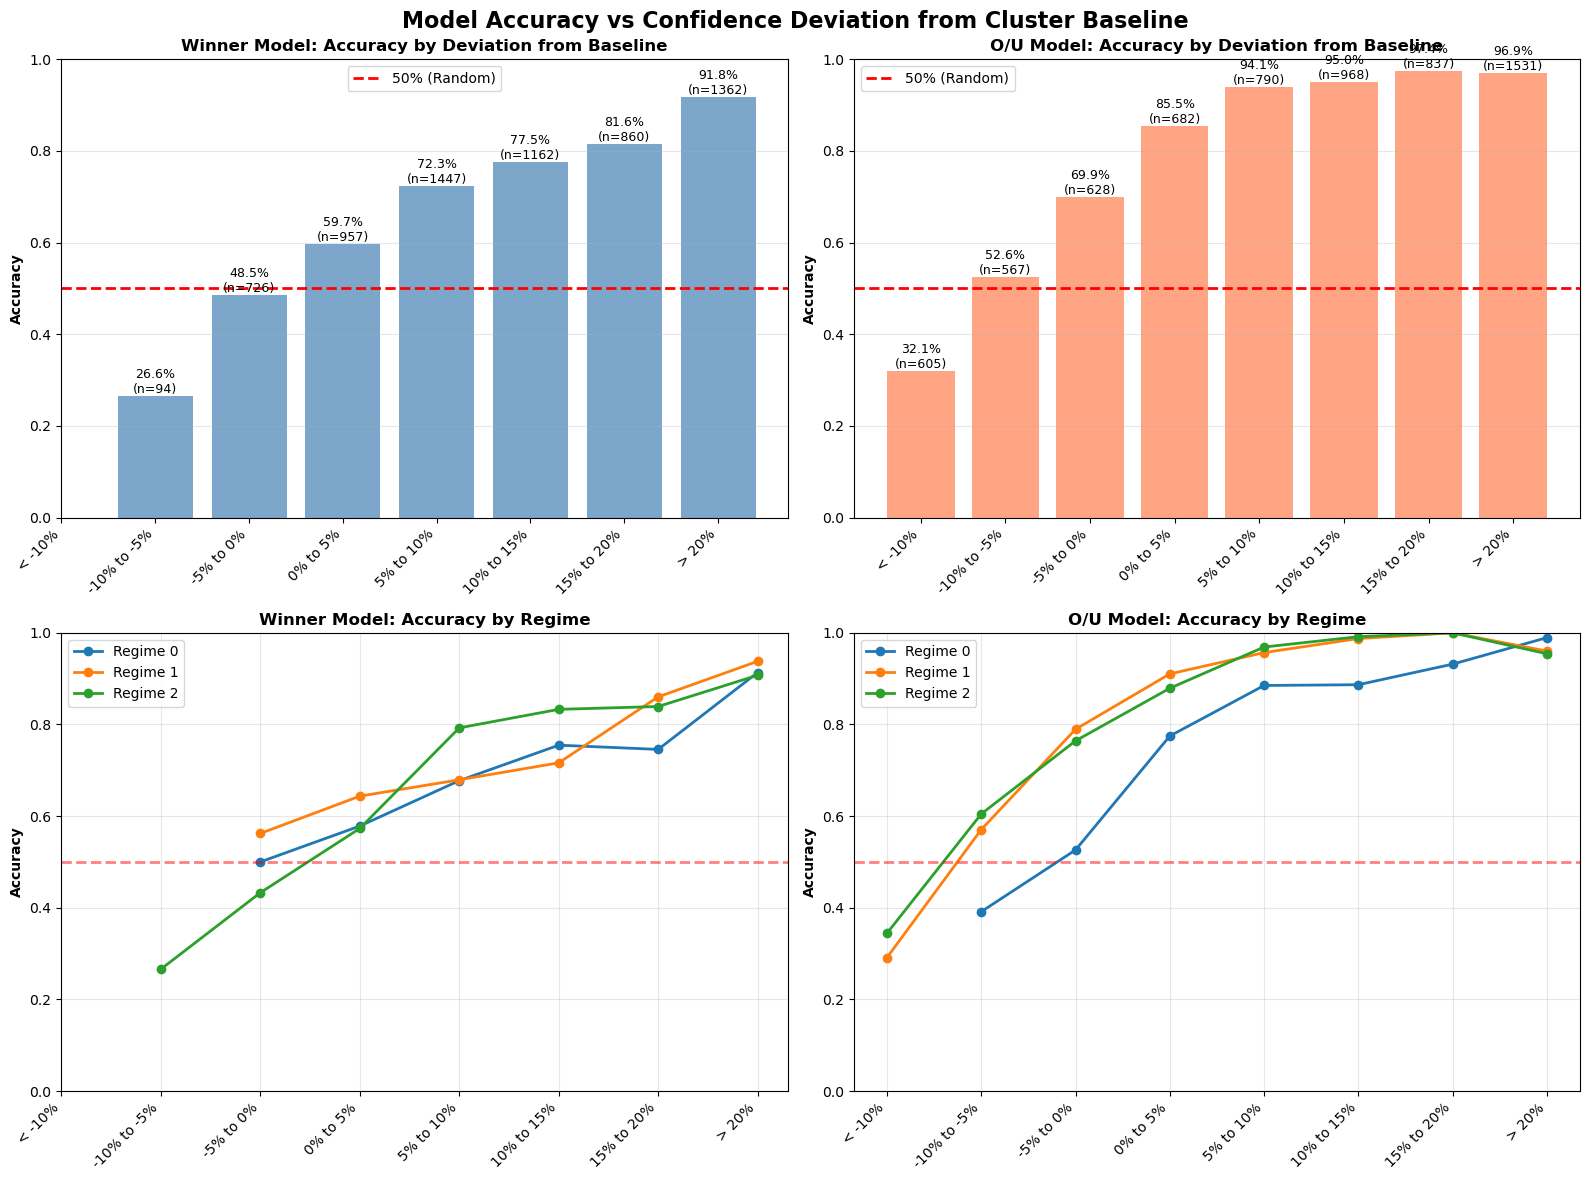


📈 ACCURACY BY CONFIDENCE DEVIATION

TYPE                O/U    WINNER
DEVIATION_BIN                    
< -10%         0.320661       NaN
-10% to -5%    0.525573  0.265957
-5% to 0%      0.699045  0.484848
0% to 5%       0.854839  0.596656
5% to 10%      0.940506  0.722875
10% to 15%     0.950413  0.775387
15% to 20%     0.973716  0.816279
> 20%          0.969301  0.917768

📊 OVERALL STATISTICS

WINNER Model:
  Above Baseline (Bolded): 77.2% accuracy (n=5788)
  At/Below Baseline:       46.0% accuracy (n=820)
  Overall:                 73.4% accuracy (n=6608)

O/U Model:
  Above Baseline (Bolded): 94.5% accuracy (n=4808)
  At/Below Baseline:       51.7% accuracy (n=1800)
  Overall:                 82.9% accuracy (n=6608)

✅ ANALYSIS COMPLETE


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# MODEL ACCURACY vs CLUSTER BASELINE DEVIATION
# ==============================================================================

print("="*70)
print("📊 ANALYZING MODEL ACCURACY BY CONFIDENCE DEVIATION")
print("="*70)

# Collect predictions and actuals for each regime
regime_analysis = []

for rid in sorted(train_m['REGIME_ID'].unique()):
    cluster_df = train_m[train_m['REGIME_ID'] == rid]
    
    # Get baseline rates
    baseline_home_win = regime_baseline_rates[rid]['home_win_rate']
    baseline_over = regime_baseline_rates[rid]['over_rate']
    
    # Get model predictions
    if rid in cluster_models and rid in ou_models:
        # Winner predictions
        X_win = cluster_df[win_features].fillna(0)
        y_win_true = cluster_df['HOME_WIN']
        win_probs = cluster_models[rid].predict_proba(X_win)[:, 1]
        win_preds = (win_probs >= 0.5).astype(int)
        
        # O/U predictions
        X_ou = cluster_df[ou_features].fillna(0)
        y_ou_true = cluster_df['OVER']
        ou_probs = ou_models[rid].predict_proba(X_ou)[:, 1]
        ou_preds = (ou_probs >= 0.5).astype(int)
        
        # Calculate confidence (max of both classes)
        win_confidence = np.maximum(win_probs, 1 - win_probs)
        ou_confidence = np.maximum(ou_probs, 1 - ou_probs)
        
        # Calculate deviation from baseline
        # For winner: deviation = |confidence - baseline|
        # For home wins: use baseline_home_win
        # For away wins: use (1 - baseline_home_win)
        win_baseline_for_pred = np.where(win_preds == 1, baseline_home_win, 1 - baseline_home_win)
        win_deviation = win_confidence - win_baseline_for_pred
        
        # For O/U: similar logic
        ou_baseline_for_pred = np.where(ou_preds == 1, baseline_over, 1 - baseline_over)
        ou_deviation = ou_confidence - ou_baseline_for_pred
        
        # Store results
        for i in range(len(cluster_df)):
            regime_analysis.append({
                'REGIME': rid,
                'TYPE': 'WINNER',
                'CONFIDENCE': win_confidence[i],
                'DEVIATION': win_deviation[i],
                'CORRECT': int(win_preds[i] == y_win_true.iloc[i]),
                'BASELINE': win_baseline_for_pred[i]
            })
            
            regime_analysis.append({
                'REGIME': rid,
                'TYPE': 'O/U',
                'CONFIDENCE': ou_confidence[i],
                'DEVIATION': ou_deviation[i],
                'CORRECT': int(ou_preds[i] == y_ou_true.iloc[i]),
                'BASELINE': ou_baseline_for_pred[i]
            })

# Convert to DataFrame
df_analysis = pd.DataFrame(regime_analysis)

# ==============================================================================
# BINNED ACCURACY ANALYSIS
# ==============================================================================

# Create deviation bins
bins = [-1, -0.1, -0.05, 0, 0.05, 0.1, 0.15, 0.2, 1]
labels = ['< -10%', '-10% to -5%', '-5% to 0%', '0% to 5%', '5% to 10%', '10% to 15%', '15% to 20%', '> 20%']
df_analysis['DEVIATION_BIN'] = pd.cut(df_analysis['DEVIATION'], bins=bins, labels=labels)

# Calculate accuracy by deviation bin
accuracy_by_bin = df_analysis.groupby(['TYPE', 'DEVIATION_BIN'])['CORRECT'].agg(['mean', 'count']).reset_index()
accuracy_by_bin.columns = ['TYPE', 'DEVIATION_BIN', 'ACCURACY', 'COUNT']

# ==============================================================================
# VISUALIZATIONS
# ==============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Accuracy vs Confidence Deviation from Cluster Baseline', fontsize=16, fontweight='bold')

# 1. Winner Model: Accuracy by Deviation Bin
ax1 = axes[0, 0]
winner_data = accuracy_by_bin[accuracy_by_bin['TYPE'] == 'WINNER']
bars1 = ax1.bar(range(len(winner_data)), winner_data['ACCURACY'], color='steelblue', alpha=0.7)
ax1.set_xticks(range(len(winner_data)))
ax1.set_xticklabels(winner_data['DEVIATION_BIN'], rotation=45, ha='right')
ax1.set_ylabel('Accuracy', fontweight='bold')
ax1.set_title('Winner Model: Accuracy by Deviation from Baseline', fontweight='bold')
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='50% (Random)')
ax1.set_ylim([0, 1])
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Add value labels and sample counts
for i, (bar, acc, count) in enumerate(zip(bars1, winner_data['ACCURACY'], winner_data['COUNT'])):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.1%}\n(n={count})',
             ha='center', va='bottom', fontsize=9)

# 2. O/U Model: Accuracy by Deviation Bin
ax2 = axes[0, 1]
ou_data = accuracy_by_bin[accuracy_by_bin['TYPE'] == 'O/U']
bars2 = ax2.bar(range(len(ou_data)), ou_data['ACCURACY'], color='coral', alpha=0.7)
ax2.set_xticks(range(len(ou_data)))
ax2.set_xticklabels(ou_data['DEVIATION_BIN'], rotation=45, ha='right')
ax2.set_ylabel('Accuracy', fontweight='bold')
ax2.set_title('O/U Model: Accuracy by Deviation from Baseline', fontweight='bold')
ax2.axhline(y=0.5, color='red', linestyle='--', linewidth=2, label='50% (Random)')
ax2.set_ylim([0, 1])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# Add value labels and sample counts
for i, (bar, acc, count) in enumerate(zip(bars2, ou_data['ACCURACY'], ou_data['COUNT'])):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height,
             f'{acc:.1%}\n(n={count})',
             ha='center', va='bottom', fontsize=9)

# 3. Winner Model: Accuracy by Regime and Deviation
ax3 = axes[1, 0]
for rid in sorted(df_analysis['REGIME'].unique()):
    regime_winner = df_analysis[(df_analysis['REGIME'] == rid) & (df_analysis['TYPE'] == 'WINNER')]
    regime_acc = regime_winner.groupby('DEVIATION_BIN')['CORRECT'].mean()
    ax3.plot(range(len(regime_acc)), regime_acc.values, marker='o', label=f'Regime {rid}', linewidth=2)

ax3.set_xticks(range(len(labels)))
ax3.set_xticklabels(labels, rotation=45, ha='right')
ax3.set_ylabel('Accuracy', fontweight='bold')
ax3.set_title('Winner Model: Accuracy by Regime', fontweight='bold')
ax3.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax3.set_ylim([0, 1])
ax3.legend()
ax3.grid(alpha=0.3)

# 4. O/U Model: Accuracy by Regime and Deviation
ax4 = axes[1, 1]
for rid in sorted(df_analysis['REGIME'].unique()):
    regime_ou = df_analysis[(df_analysis['REGIME'] == rid) & (df_analysis['TYPE'] == 'O/U')]
    regime_acc = regime_ou.groupby('DEVIATION_BIN')['CORRECT'].mean()
    ax4.plot(range(len(regime_acc)), regime_acc.values, marker='o', label=f'Regime {rid}', linewidth=2)

ax4.set_xticks(range(len(labels)))
ax4.set_xticklabels(labels, rotation=45, ha='right')
ax4.set_ylabel('Accuracy', fontweight='bold')
ax4.set_title('O/U Model: Accuracy by Regime', fontweight='bold')
ax4.axhline(y=0.5, color='red', linestyle='--', linewidth=2, alpha=0.5)
ax4.set_ylim([0, 1])
ax4.legend()
ax4.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# ==============================================================================
# SUMMARY TABLE
# ==============================================================================

print("\n" + "="*70)
print("📈 ACCURACY BY CONFIDENCE DEVIATION")
print("="*70)

summary_table = accuracy_by_bin.pivot(index='DEVIATION_BIN', columns='TYPE', values='ACCURACY')
print("\n" + summary_table.to_string())

# Overall statistics
print("\n" + "="*70)
print("📊 OVERALL STATISTICS")
print("="*70)

for pred_type in ['WINNER', 'O/U']:
    type_data = df_analysis[df_analysis['TYPE'] == pred_type]
    
    # Split into above and below baseline
    above_baseline = type_data[type_data['DEVIATION'] > 0]
    below_baseline = type_data[type_data['DEVIATION'] <= 0]
    
    print(f"\n{pred_type} Model:")
    print(f"  Above Baseline (Bolded): {above_baseline['CORRECT'].mean():.1%} accuracy (n={len(above_baseline)})")
    print(f"  At/Below Baseline:       {below_baseline['CORRECT'].mean():.1%} accuracy (n={len(below_baseline)})")
    print(f"  Overall:                 {type_data['CORRECT'].mean():.1%} accuracy (n={len(type_data)})")

print("\n" + "="*70)
print("✅ ANALYSIS COMPLETE")
print("="*70)